# Statistika

In [ ]:
# TODO

## Kā veidot skaistus grafikus?

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pathlib import Path

Sāksim ar vienkāršu piemēru, kā neizskatās labi:

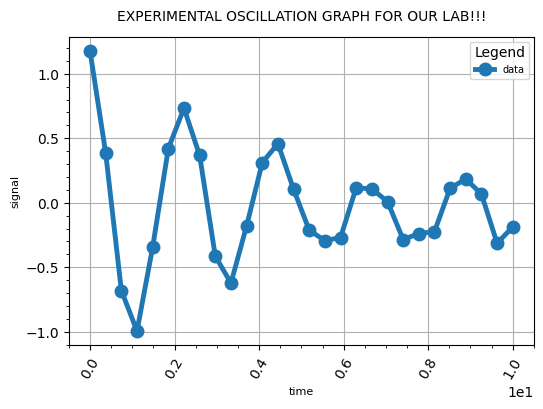

In [8]:
out_dir = Path("codes/bad_good_chart_output")
out_dir.mkdir(parents=True, exist_ok=True)

# Synthetic physics data: damped harmonic oscillator
rng = np.random.default_rng(7)
t = np.linspace(0, 10, 28)
A = 1.2
gamma = 0.22
omega = 2.8
phi = 0.2

y_true = A * np.exp(-gamma * t) * np.cos(omega * t + phi)
sigma = 0.06 + 0.015 * np.exp(0.1 * t)
y_obs = y_true + rng.normal(0, sigma)

t_fine = np.linspace(0, 10, 600)
y_model = A * np.exp(-gamma * t_fine) * np.cos(omega * t_fine + phi)

# Bad chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, y_obs, marker="o", linewidth=3.5, markersize=9, label="data")
ax.set_title("EXPERIMENTAL OSCILLATION GRAPH FOR OUR LAB!!!", fontsize=10, pad=12)
ax.set_xlabel("time", fontsize=8)
ax.set_ylabel("signal", fontsize=8)
ax.grid(True)
ax.minorticks_on()
ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))

for label in ax.get_xticklabels():
    label.set_rotation(60)

ax.legend(loc="upper right", fontsize=7, title="Legend")

bad_path = out_dir / "physics_chart_bad.png"
fig.savefig(bad_path, dpi=200, bbox_inches="tight")
plt.show()

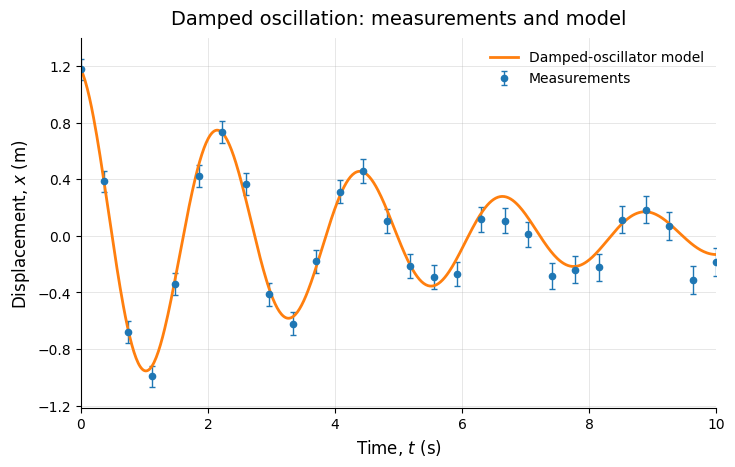

In [11]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.errorbar(
    t,
    y_obs,
    yerr=sigma,
    fmt="o",
    capsize=2.5,
    elinewidth=1.0,
    markersize=4.5,
    label="Measurements",
)
ax.plot(t_fine, y_model, linewidth=2.0, label="Damped-oscillator model")

ax.set_title("Damped oscillation: measurements and model", fontsize=14, pad=10)
ax.set_xlabel("Time, $t$ (s)", fontsize=12)
ax.set_ylabel("Displacement, $x$ (m)", fontsize=12)

ax.set_xlim(0, 10)
y_pad = 0.12
ax.set_ylim(
    min(y_obs.min() - sigma.max(), y_model.min()) - y_pad,
    max(y_obs.max() + sigma.max(), y_model.max()) + y_pad,
)

ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(7))
ax.tick_params(axis="both", labelsize=10)
ax.grid(True, linewidth=0.6, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=10, loc="upper right")

good_path = out_dir / "physics_chart_good.png"
fig.savefig(good_path, dpi=200, bbox_inches="tight")
plt.show()

Slikts piemērs violin plotam:

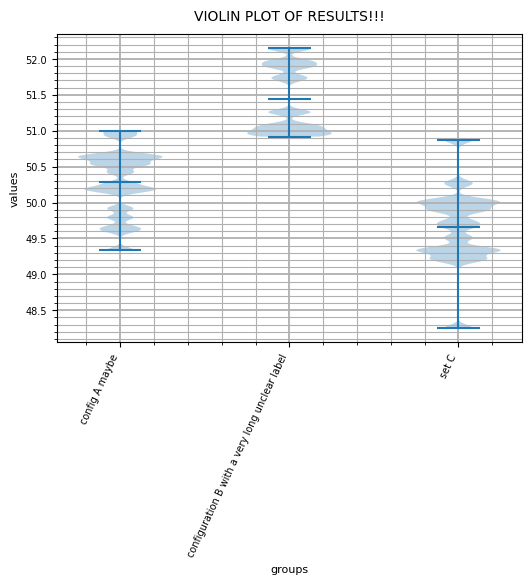

In [5]:
out_dir = Path("codes/bad_good_chart_output")
out_dir.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(12)

group_a = rng.normal(50.2, 0.45, 18)
group_b = np.concatenate([
    rng.normal(51.1, 0.25, 10),
    rng.normal(52.0, 0.18, 8),
])
group_c = rng.normal(49.6, 0.70, 16)

data = [group_a, group_b, group_c]
labels_bad = [
    "config A maybe",
    "configuration B with a very long unclear label",
    "set C",
]

# Bad violin plot
fig, ax = plt.subplots(figsize=(6, 4))

parts = ax.violinplot(
    data,
    showmeans=True,
    showmedians=False,
    showextrema=True,
    bw_method=0.08,
    points=300,
)

ax.set_title("VIOLIN PLOT OF RESULTS!!!", fontsize=10, pad=10)
ax.set_xlabel("groups", fontsize=8)
ax.set_ylabel("values", fontsize=8)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels_bad, rotation=65, ha="right", fontsize=7)
ax.tick_params(axis="y", labelsize=7)
ax.grid(True, linewidth=1.3)
ax.minorticks_on()
ax.grid(True, which="minor", linewidth=0.8)

bad_path = out_dir / "violin_chart_bad.png"
fig.savefig(bad_path, dpi=200, bbox_inches="tight")

plt.show()

Aptuveni labs piemērs violin plotam:

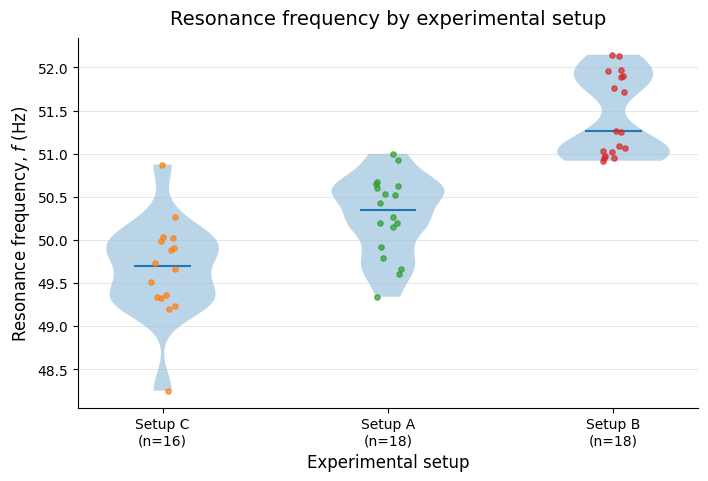

In [6]:
group_info = [
    ("Setup C\n(n=16)", group_c),
    ("Setup A\n(n=18)", group_a),
    ("Setup B\n(n=18)", group_b),
]
group_info.sort(key=lambda item: np.median(item[1]))
labels_good = [item[0] for item in group_info]
data_good = [item[1] for item in group_info]

fig, ax = plt.subplots(figsize=(8.0, 4.8))

parts = ax.violinplot(
    data_good,
    showmeans=False,
    showmedians=True,
    showextrema=False,
    bw_method=0.35,
    points=200,
)

# Overlay raw observations with light horizontal jitter
for i, values in enumerate(data_good, start=1):
    jitter = rng.uniform(-0.06, 0.06, size=len(values))
    ax.plot(
        np.full(len(values), i) + jitter,
        values,
        "o",
        markersize=3.8,
        alpha=0.7,
    )

ax.set_title("Resonance frequency by experimental setup", fontsize=14, pad=10)
ax.set_xlabel("Experimental setup", fontsize=12)
ax.set_ylabel("Resonance frequency, $f$ (Hz)", fontsize=12)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels_good, fontsize=10)
ax.tick_params(axis="y", labelsize=10)

ax.grid(True, axis="y", linewidth=0.6, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

good_path = out_dir / "violin_chart_good.png"
fig.savefig(good_path, dpi=200, bbox_inches="tight")
plt.show()

Papildus resursi:
- https://www.storytellingwithdata.com/makeovers
- https://clauswilke.com/dataviz/
- https://python-graph-gallery.com/
- https://handsondataviz.org/chartdesign.html
- https://www.nature.com/documents/natrevartworkguide_PS.pdf
- https://wwnorton.com/books/978132400156
- https://towardsdatascience.com/creatingscientific-plots-the-easy-way-withscienceplots-and-matplotlib-d86a62e2ab46/